In [1]:
#PARAMETERS (for papermill)

# Đường dẫn dữ liệu đã có flags anomaly từ notebook 02
INPUT_DATA_PATH = "data/processed/data_with_anomaly_flags.parquet"

# Thư mục lưu kết quả
OUTPUT_DIR = "data/processed"

# Tên file output
FEATURE_OUTPUT_FILENAME = "feature_engineered_data.parquet"

# Cột mục tiêu (cần dự báo)
TARGET_COLUMN = "Global_active_power"

# Tham số cho lag features
LAG_HOURS = [1, 2, 3, 6, 12, 24, 48]  # Lag theo giờ

# Tham số cho rolling features
ROLLING_WINDOWS = [6, 12, 24, 48]  # Cửa sổ tính trung bình động (giờ)

# Có tạo các features thời gian không?
CREATE_TIME_FEATURES = True

# Có tạo lag features không?
CREATE_LAG_FEATURES = True

# Có tạo rolling features không?
CREATE_ROLLING_FEATURES = True

# Bật/tắt các biểu đồ
PLOT_FEATURE_CORRELATION = True
PLOT_FEATURE_DISTRIBUTION = True
PLOT_TARGET_VS_FEATURES = True

In [2]:
# Parameters
INPUT_DATA_PATH = "data/processed/data_with_anomaly_flags.parquet"
OUTPUT_DIR = "data/processed"
FEATURE_OUTPUT_FILENAME = "feature_engineered_data.parquet"
TARGET_COLUMN = "Global_active_power"
LAG_HOURS = [1, 2, 3, 6, 12, 24, 48]
ROLLING_WINDOWS = [6, 12, 24, 48]
CREATE_TIME_FEATURES = True
CREATE_LAG_FEATURES = True
CREATE_ROLLING_FEATURES = True
PLOT_FEATURE_CORRELATION = True
PLOT_FEATURE_DISTRIBUTION = True
PLOT_TARGET_VS_FEATURES = True


In [3]:
# ==================== SETUP ====================
%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Xác định project_root linh hoạt
cwd = os.getcwd()
if os.path.basename(cwd) == "notebooks":
    project_root = os.path.abspath("..")
else:
    project_root = cwd

src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.append(src_path)

# Import thư viện tự viết
from energy_forecast_library import DataLoader, FeatureEngineer, Utils

# Tạo thư mục output nếu chưa có
os.makedirs(os.path.join(project_root, OUTPUT_DIR), exist_ok=True)
os.makedirs(os.path.join(project_root, "outputs/figures"), exist_ok=True)

print(f"✅ Project root: {project_root}")
print(f"✅ Output dir: {OUTPUT_DIR}")
print("✅ Đã import thư viện thành công")

✅ Project root: C:\Users\Admin\DataMining\nhom_13_Household_Power
✅ Output dir: data/processed
✅ Đã import thư viện thành công


In [4]:
# ==================== LOAD DATA ====================
data_path = os.path.join(project_root, INPUT_DATA_PATH)

if not os.path.exists(data_path):
    print(f"❌ Không tìm thấy file: {data_path}")
    print("Vui lòng chạy notebook 02 trước!")
else:
    df = DataLoader.load_processed_data(data_path)
    
    print(f"✅ Đã tải dữ liệu từ: {INPUT_DATA_PATH}")
    print(f"📊 Kích thước: {df.shape[0]:,} dòng, {df.shape[1]} cột")
    print(f"📅 Thời gian: {df.index.min()} → {df.index.max()}")
    print(f"📌 Các cột hiện có: {list(df.columns)}")
    
    df.head()

✅ Đã đọc 2,075,259 dòng từ data_with_anomaly_flags.parquet
✅ Đã tải dữ liệu từ: data/processed/data_with_anomaly_flags.parquet
📊 Kích thước: 2,075,259 dòng, 14 cột
📅 Thời gian: 2006-12-16 17:24:00 → 2010-11-26 21:02:00
📌 Các cột hiện có: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'is_anomaly_zscore', 'is_anomaly_iqr', 'is_anomaly', 'hour', 'dayofweek', 'month', 'year']


In [5]:
# ==================== TẠO TIME FEATURES ====================
if CREATE_TIME_FEATURES:
    print("⏰ Đang tạo các đặc trưng thời gian...")
    
    df = FeatureEngineer.create_time_features(df)
    
    print("✅ Đã tạo các features:")
    print("   - hour, day, month, year, dayofweek, quarter, dayofyear, weekofyear")
    print("   - is_weekend, is_month_start, is_month_end")
    print("   - hour_sin, hour_cos, month_sin, month_cos (cyclical encoding)")
    
    print(f"\n📊 Kích thước mới: {df.shape[0]:,} dòng, {df.shape[1]} cột")
    
    # Hiển thị các cột mới
    new_cols = ['hour', 'day', 'month', 'year', 'dayofweek', 'quarter', 
                'dayofyear', 'weekofyear', 'is_weekend', 'is_month_start', 
                'is_month_end', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
    
    df[new_cols].head()

⏰ Đang tạo các đặc trưng thời gian...


✅ Đã tạo các features:
   - hour, day, month, year, dayofweek, quarter, dayofyear, weekofyear
   - is_weekend, is_month_start, is_month_end
   - hour_sin, hour_cos, month_sin, month_cos (cyclical encoding)

📊 Kích thước mới: 2,075,259 dòng, 25 cột


In [6]:
# ==================== TẠO LAG FEATURES ====================
if CREATE_LAG_FEATURES:
    print(f"⏰ Đang tạo lag features với các lag: {LAG_HOURS} giờ...")
    
    df = FeatureEngineer.create_lag_features(df, column=TARGET_COLUMN, lags=LAG_HOURS)
    
    print("✅ Đã tạo các lag features:")
    for lag in LAG_HOURS:
        print(f"   - {TARGET_COLUMN}_lag_{lag}")
    
    print(f"\n📊 Kích thước mới: {df.shape[0]:,} dòng, {df.shape[1]} cột")
    
    # Hiển thị các cột lag mới
    lag_cols = [f'{TARGET_COLUMN}_lag_{lag}' for lag in LAG_HOURS]
    df[lag_cols].head()

⏰ Đang tạo lag features với các lag: [1, 2, 3, 6, 12, 24, 48] giờ...


✅ Đã tạo các lag features:
   - Global_active_power_lag_1
   - Global_active_power_lag_2
   - Global_active_power_lag_3
   - Global_active_power_lag_6
   - Global_active_power_lag_12
   - Global_active_power_lag_24
   - Global_active_power_lag_48

📊 Kích thước mới: 2,075,259 dòng, 32 cột


In [7]:
# ==================== TẠO ROLLING FEATURES ====================
if CREATE_ROLLING_FEATURES:
    print(f"⏰ Đang tạo rolling features với các windows: {ROLLING_WINDOWS} giờ...")
    
    df = FeatureEngineer.create_rolling_features(df, column=TARGET_COLUMN, windows=ROLLING_WINDOWS)
    
    print("✅ Đã tạo các rolling features:")
    for window in ROLLING_WINDOWS:
        print(f"   - {TARGET_COLUMN}_roll_mean_{window}")
        print(f"   - {TARGET_COLUMN}_roll_std_{window}")
        print(f"   - {TARGET_COLUMN}_roll_min_{window}")
        print(f"   - {TARGET_COLUMN}_roll_max_{window}")
    
    print(f"\n📊 Kích thước mới: {df.shape[0]:,} dòng, {df.shape[1]} cột")
    
    # Hiển thị các cột rolling mới
    rolling_cols = []
    for window in ROLLING_WINDOWS:
        rolling_cols.extend([
            f'{TARGET_COLUMN}_roll_mean_{window}',
            f'{TARGET_COLUMN}_roll_std_{window}',
            f'{TARGET_COLUMN}_roll_min_{window}',
            f'{TARGET_COLUMN}_roll_max_{window}'
        ])
    
    df[rolling_cols].head()

⏰ Đang tạo rolling features với các windows: [6, 12, 24, 48] giờ...


✅ Đã tạo các rolling features:
   - Global_active_power_roll_mean_6
   - Global_active_power_roll_std_6
   - Global_active_power_roll_min_6
   - Global_active_power_roll_max_6
   - Global_active_power_roll_mean_12
   - Global_active_power_roll_std_12
   - Global_active_power_roll_min_12
   - Global_active_power_roll_max_12
   - Global_active_power_roll_mean_24
   - Global_active_power_roll_std_24
   - Global_active_power_roll_min_24
   - Global_active_power_roll_max_24
   - Global_active_power_roll_mean_48
   - Global_active_power_roll_std_48
   - Global_active_power_roll_min_48
   - Global_active_power_roll_max_48

📊 Kích thước mới: 2,075,259 dòng, 48 cột


In [8]:
# ==================== KIỂM TRA MISSING VALUES ====================
# Các lag và rolling features sẽ tạo ra NaN ở đầu
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing': missing_count.values,
    'Percent': missing_percent.values
}).sort_values('Percent', ascending=False)

print("📊 Missing values sau khi tạo features:")
print(missing_df[missing_df['Missing'] > 0].to_string(index=False))

# Xử lý missing: drop các dòng có NaN (đầu chuỗi)
df_clean = df.dropna().copy()
print(f"\n✅ Đã drop {len(df) - len(df_clean)} dòng có NaN (đầu chuỗi thời gian)")
print(f"📊 Kích thước sau khi drop: {df_clean.shape[0]:,} dòng")

📊 Missing values sau khi tạo features:
                          Column  Missing  Percent
Global_active_power_roll_mean_48    26331 1.268805
 Global_active_power_roll_std_48    26331 1.268805
 Global_active_power_roll_min_48    26331 1.268805
 Global_active_power_roll_max_48    26331 1.268805
Global_active_power_roll_mean_24    25965 1.251169
 Global_active_power_roll_std_24    25965 1.251169
 Global_active_power_roll_min_24    25965 1.251169
 Global_active_power_roll_max_24    25965 1.251169
Global_active_power_roll_mean_12    25773 1.241917
 Global_active_power_roll_std_12    25773 1.241917
 Global_active_power_roll_min_12    25773 1.241917
 Global_active_power_roll_max_12    25773 1.241917
 Global_active_power_roll_mean_6    25677 1.237291
  Global_active_power_roll_std_6    25677 1.237291
  Global_active_power_roll_min_6    25677 1.237291
  Global_active_power_roll_max_6    25677 1.237291
      Global_active_power_lag_48    25645 1.235749
      Global_active_power_lag_24    25621 1


✅ Đã drop 26346 dòng có NaN (đầu chuỗi thời gian)
📊 Kích thước sau khi drop: 2,048,913 dòng


In [9]:
# ==================== THỐNG KÊ MÔ TẢ FEATURES MỚI ====================
# Lấy các features mới để thống kê
all_new_features = []

if CREATE_TIME_FEATURES:
    all_new_features.extend(['hour', 'day', 'month', 'dayofweek', 'is_weekend'])
    
if CREATE_LAG_FEATURES:
    all_new_features.extend([f'{TARGET_COLUMN}_lag_{lag}' for lag in LAG_HOURS[:3]])  # Lấy 3 lag đầu
    
if CREATE_ROLLING_FEATURES:
    all_new_features.extend([
        f'{TARGET_COLUMN}_roll_mean_{ROLLING_WINDOWS[0]}',
        f'{TARGET_COLUMN}_roll_std_{ROLLING_WINDOWS[0]}'
    ])

print("📊 Thống kê một số features mới:")
df_clean[all_new_features].describe()

📊 Thống kê một số features mới:


,hour,day,month,dayofweek,is_weekend,Global_active_power_lag_1,Global_active_power_lag_2,Global_active_power_lag_3,Global_active_power_roll_mean_6,Global_active_power_roll_std_6
count,2.048913e+06,2.048913e+06,2.048913e+06,2.048913e+06,2.048913e+06,2.048913e+06,2.048913e+06,2.048913e+06,2.048913e+06,2.048913e+06
mean,1.150288e+01,1.571239e+01,6.454372e+00,2.989201e+00,2.824322e-01,1.091433e+00,1.091440e+00,1.091449e+00,1.091445e+00,1.294795e-01
std,6.925486e+00,8.801755e+00,3.423194e+00,1.997558e+00,4.501826e-01,1.057143e+00,1.057150e+00,1.057160e+00,1.025506e+00,2.496742e-01
min,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,7.600000e-02,7.600000e-02,7.600000e-02,7.600000e-02,0.000000e+00
25%,5.000000e+00,8.000000e+00,3.000000e+00,1.000000e+00,0.000000e+00,3.080000e-01,3.080000e-01,3.080000e-01,3.130000e-01,6.572671e-03
50%,1.200000e+01,1.600000e+01,6.000000e+00,3.000000e+00,0.000000e+00,6.020000e-01,6.020000e-01,6.020000e-01,6.390000e-01,3.588314e-02
75%,1.800000e+01,2.300000e+01,9.000000e+00,5.000000e+00,1.000000e+00,1.528000e+00,1.528000e+00,1.528000e+00,1.545667e+00,9.165515e-02
max,2.300000e+01,3.100000e+01,1.200000e+01,6.000000e+00,1.000000e+00,1.112200e+01,1.112200e+01,1.112200e+01,9.720667e+00,3.231762e+00


📊 Top 10 features tương quan mạnh nhất với target:
                         feature  correlation
                Global_intensity     0.998888
       Global_active_power_lag_1     0.968044
 Global_active_power_roll_mean_6     0.956119
  Global_active_power_roll_max_6     0.941311
       Global_active_power_lag_2     0.933778
  Global_active_power_roll_min_6     0.923476
Global_active_power_roll_mean_12     0.916542
       Global_active_power_lag_3     0.906645
 Global_active_power_roll_max_12     0.897903
Global_active_power_roll_mean_24     0.864685

📊 Top 10 features tương quan nghịch mạnh nhất:
       feature  correlation
     month_sin    -0.000695
is_month_start    -0.009472
     dayofyear    -0.031756
    weekofyear    -0.032589
         month    -0.032787
          year    -0.034305
       quarter    -0.039141
      hour_cos    -0.110433
      hour_sin    -0.188114
       Voltage    -0.399724


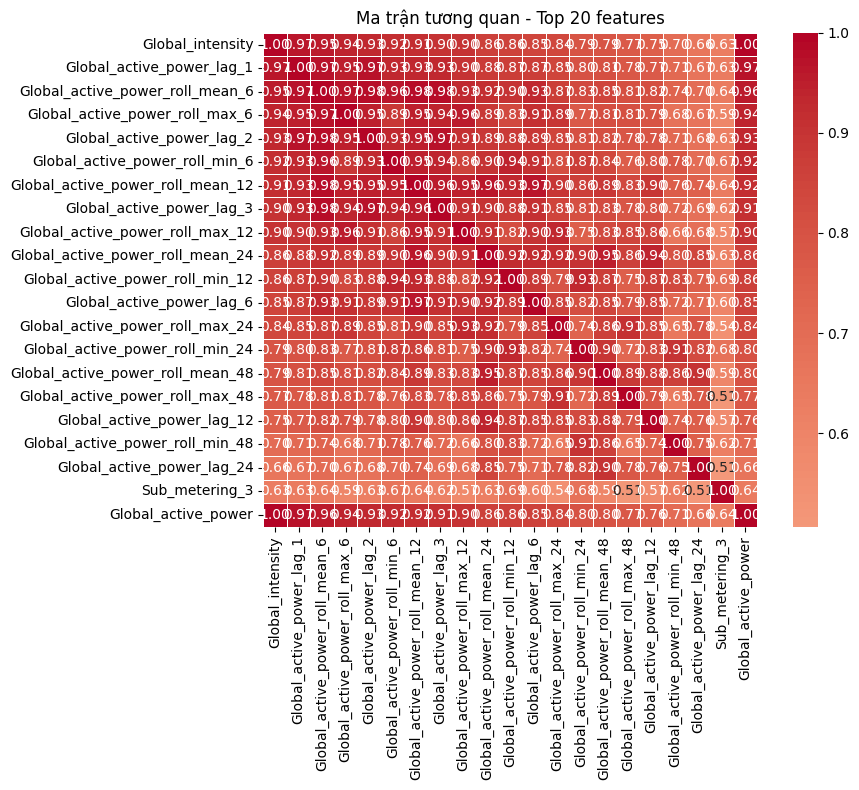

In [10]:
# ==================== TƯƠNG QUAN VỚI TARGET ====================
if PLOT_FEATURE_CORRELATION:
    # Chọn các features số để tính tương quan
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if col not in ['is_anomaly', 'is_anomaly_zscore', 'is_anomaly_iqr']]
    
    # Tính tương quan với target
    correlations = []
    for col in numeric_cols:
        if col != TARGET_COLUMN:
            corr = df_clean[[TARGET_COLUMN, col]].corr().iloc[0,1]
            correlations.append({'feature': col, 'correlation': corr})
    
    corr_df = pd.DataFrame(correlations).sort_values('correlation', ascending=False)
    
    print("📊 Top 10 features tương quan mạnh nhất với target:")
    print(corr_df.head(10).to_string(index=False))
    
    print("\n📊 Top 10 features tương quan nghịch mạnh nhất:")
    print(corr_df.tail(10).to_string(index=False))
    
    # Vẽ biểu đồ tương quan
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Lấy top 20 features
    top_features = corr_df.head(20)['feature'].tolist()
    top_features.append(TARGET_COLUMN)
    
    corr_matrix = df_clean[top_features].corr()
    
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                fmt='.2f', square=True, linewidths=0.5, ax=ax)
    ax.set_title('Ma trận tương quan - Top 20 features')
    
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'outputs/figures/feature_correlation.png'), 
                dpi=100, bbox_inches='tight')
    plt.show()

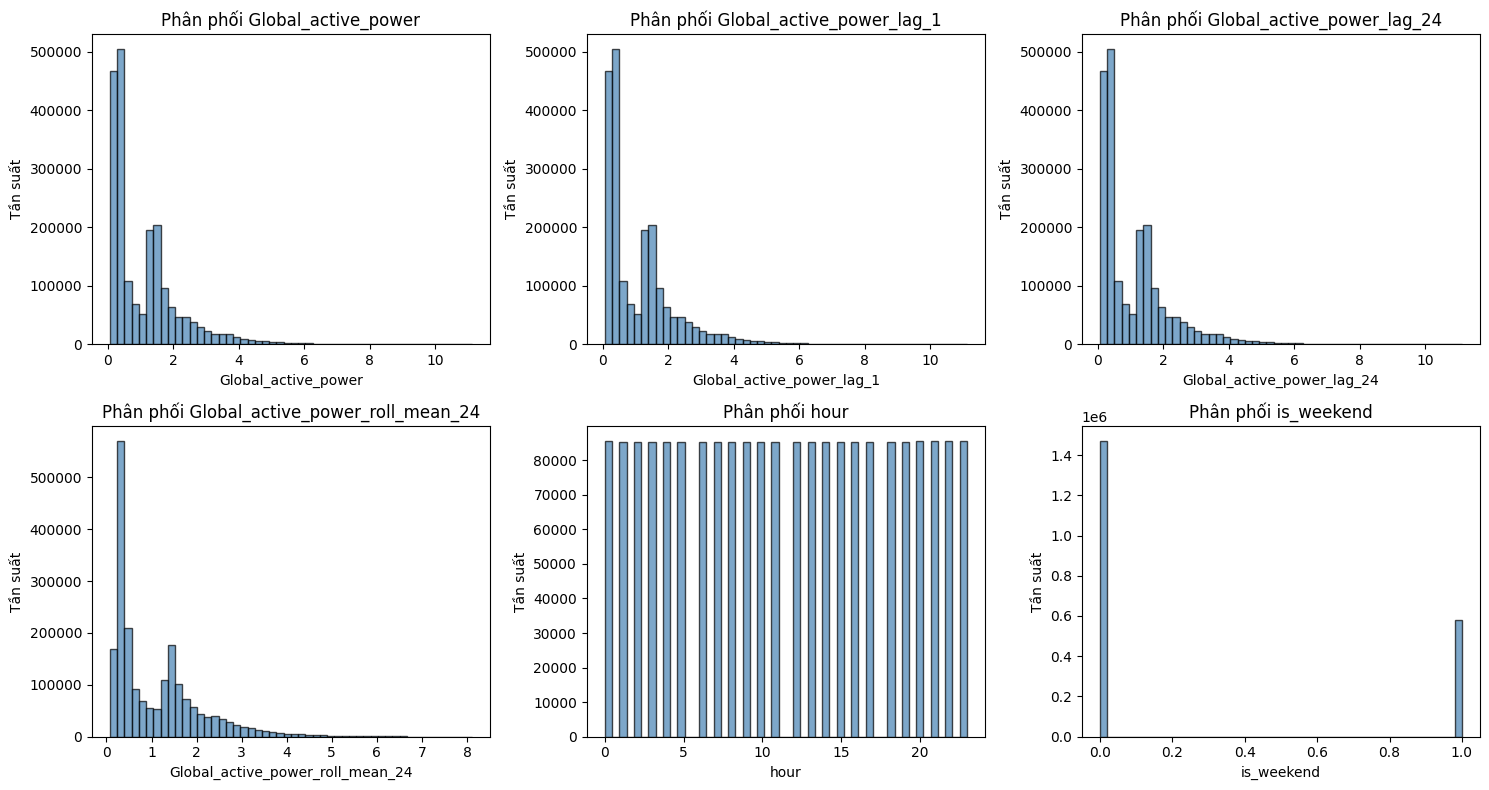

In [11]:
# ==================== PHÂN PHỐI FEATURES QUAN TRỌNG ====================
if PLOT_FEATURE_DISTRIBUTION:
    # Chọn 6 features quan trọng nhất
    important_features = [
        TARGET_COLUMN,
        f'{TARGET_COLUMN}_lag_1',
        f'{TARGET_COLUMN}_lag_24',
        f'{TARGET_COLUMN}_roll_mean_24',
        'hour',
        'is_weekend'
    ]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for idx, feature in enumerate(important_features):
        if feature in df_clean.columns:
            axes[idx].hist(df_clean[feature].dropna(), bins=50, 
                          edgecolor='black', alpha=0.7, color='steelblue')
            axes[idx].set_title(f'Phân phối {feature}')
            axes[idx].set_xlabel(feature)
            axes[idx].set_ylabel('Tần suất')
    
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'outputs/figures/feature_distributions.png'), 
                dpi=100, bbox_inches='tight')
    plt.show()

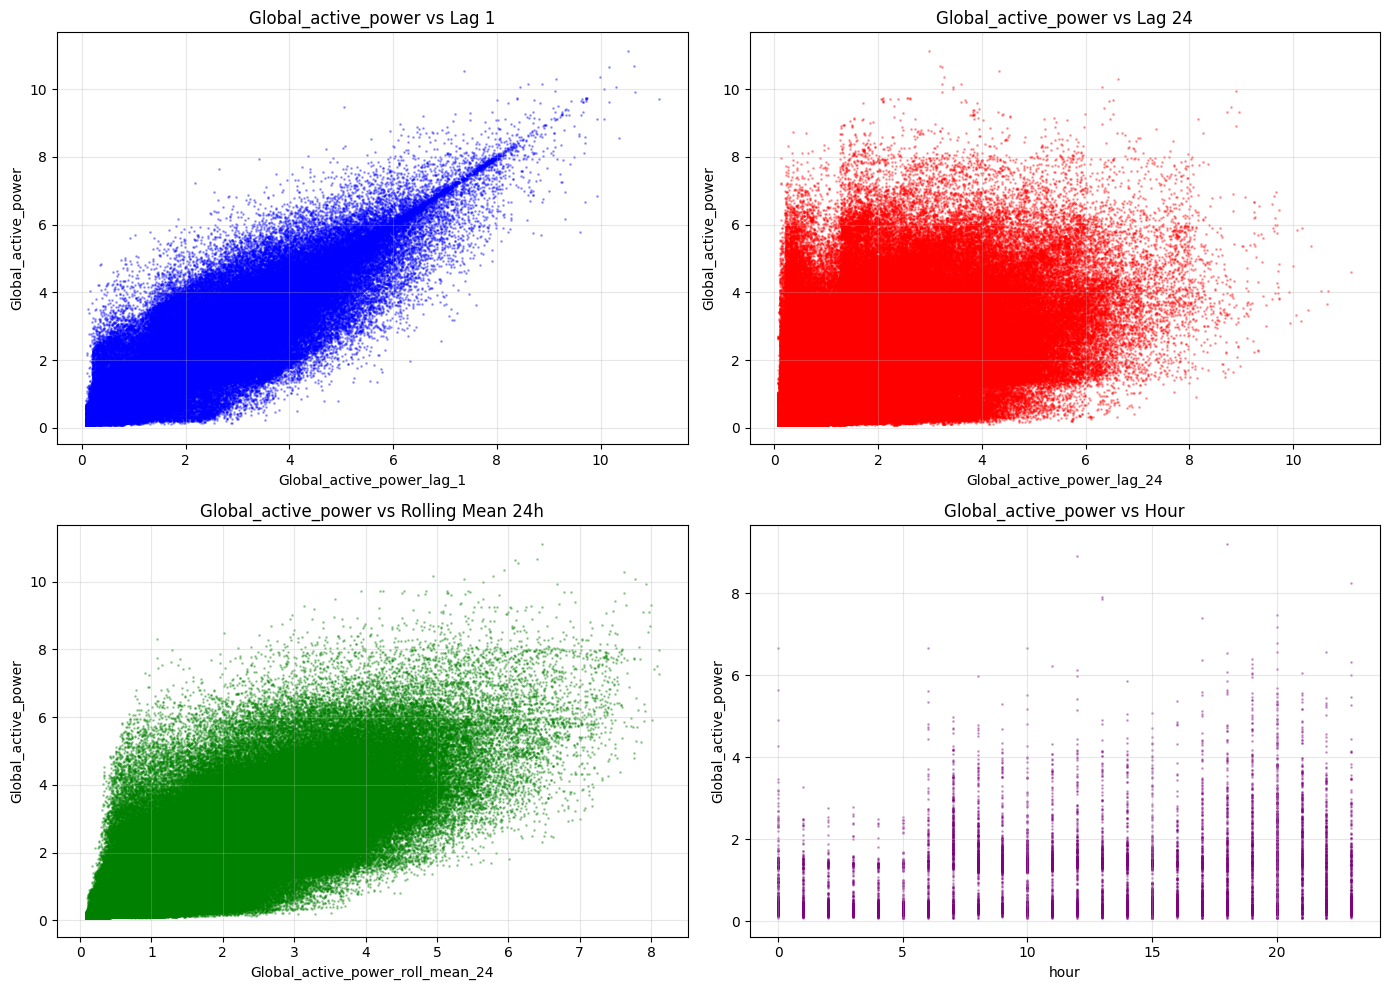

In [12]:
# ==================== TARGET VS FEATURES ====================
if PLOT_TARGET_VS_FEATURES:
    # Vẽ scatter plot giữa target và các features quan trọng
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    # Feature 1: Lag 1
    axes[0].scatter(df_clean[f'{TARGET_COLUMN}_lag_1'], df_clean[TARGET_COLUMN], 
                    alpha=0.3, s=1, color='blue')
    axes[0].set_xlabel(f'{TARGET_COLUMN}_lag_1')
    axes[0].set_ylabel(TARGET_COLUMN)
    axes[0].set_title(f'{TARGET_COLUMN} vs Lag 1')
    axes[0].grid(True, alpha=0.3)
    
    # Feature 2: Lag 24
    axes[1].scatter(df_clean[f'{TARGET_COLUMN}_lag_24'], df_clean[TARGET_COLUMN], 
                    alpha=0.3, s=1, color='red')
    axes[1].set_xlabel(f'{TARGET_COLUMN}_lag_24')
    axes[1].set_ylabel(TARGET_COLUMN)
    axes[1].set_title(f'{TARGET_COLUMN} vs Lag 24')
    axes[1].grid(True, alpha=0.3)
    
    # Feature 3: Rolling mean 24
    axes[2].scatter(df_clean[f'{TARGET_COLUMN}_roll_mean_24'], df_clean[TARGET_COLUMN], 
                    alpha=0.3, s=1, color='green')
    axes[2].set_xlabel(f'{TARGET_COLUMN}_roll_mean_24')
    axes[2].set_ylabel(TARGET_COLUMN)
    axes[2].set_title(f'{TARGET_COLUMN} vs Rolling Mean 24h')
    axes[2].grid(True, alpha=0.3)
    
    # Feature 4: Hour
    # Lấy mẫu để vẽ (tránh quá nhiều điểm)
    sample_idx = np.random.choice(len(df_clean), size=10000, replace=False)
    axes[3].scatter(df_clean.iloc[sample_idx]['hour'], df_clean.iloc[sample_idx][TARGET_COLUMN], 
                    alpha=0.3, s=1, color='purple')
    axes[3].set_xlabel('hour')
    axes[3].set_ylabel(TARGET_COLUMN)
    axes[3].set_title(f'{TARGET_COLUMN} vs Hour')
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'outputs/figures/target_vs_features.png'), 
                dpi=100, bbox_inches='tight')
    plt.show()

In [13]:
# ==================== THÔNG TIN TỔNG HỢP ====================
print("="*60)
print("📊 TỔNG KẾT FEATURE ENGINEERING")
print("="*60)

print(f"\n📌 Tổng số features: {df_clean.shape[1]}")
print(f"📌 Số dòng dữ liệu: {df_clean.shape[0]:,}")
print(f"📌 Khoảng thời gian: {df_clean.index.min()} → {df_clean.index.max()}")

# Phân loại features
original_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 
                 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
anomaly_cols = ['is_anomaly', 'is_anomaly_zscore', 'is_anomaly_iqr']
time_cols = ['hour', 'day', 'month', 'year', 'dayofweek', 'quarter', 'dayofyear', 
             'weekofyear', 'is_weekend', 'is_month_start', 'is_month_end',
             'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
lag_cols = [col for col in df_clean.columns if 'lag' in col]
rolling_cols = [col for col in df_clean.columns if 'roll' in col]

print(f"\n📌 Phân loại:")
print(f"   - Features gốc: {len([c for c in original_cols if c in df_clean.columns])}")
print(f"   - Anomaly flags: {len([c for c in anomaly_cols if c in df_clean.columns])}")
print(f"   - Time features: {len([c for c in time_cols if c in df_clean.columns])}")
print(f"   - Lag features: {len(lag_cols)}")
print(f"   - Rolling features: {len(rolling_cols)}")

# Kiểm tra missing
missing_after = df_clean.isna().sum().sum()
print(f"\n✅ Missing values: {missing_after} (đã xử lý hết)")

📊 TỔNG KẾT FEATURE ENGINEERING

📌 Tổng số features: 48
📌 Số dòng dữ liệu: 2,048,913
📌 Khoảng thời gian: 2006-12-16 18:12:00 → 2010-11-26 21:02:00

📌 Phân loại:
   - Features gốc: 7
   - Anomaly flags: 3
   - Time features: 15
   - Lag features: 7
   - Rolling features: 16

✅ Missing values: 0 (đã xử lý hết)


In [14]:
# ==================== LƯU DỮ LIỆU ====================
output_path = os.path.join(project_root, OUTPUT_DIR, FEATURE_OUTPUT_FILENAME)
Utils.save_dataframe(df_clean, output_path)

# Lưu thêm thông tin về features
feature_info = {
    'total_features': df_clean.shape[1],
    'total_samples': df_clean.shape[0],
    'time_range': f"{df_clean.index.min()} to {df_clean.index.max()}",
    'original_features': [c for c in original_cols if c in df_clean.columns],
    'time_features': [c for c in time_cols if c in df_clean.columns],
    'lag_features': lag_cols,
    'rolling_features': rolling_cols
}

import json
info_path = os.path.join(project_root, OUTPUT_DIR, 'feature_info.json')
with open(info_path, 'w') as f:
    json.dump(feature_info, f, indent=2, default=str)

print("\n✅ Đã lưu dữ liệu thành công:")
print(f"   - File dữ liệu: {FEATURE_OUTPUT_FILENAME}")
print(f"   - File thông tin: feature_info.json")
print(f"   - Kích thước: {df_clean.shape[0]:,} dòng, {df_clean.shape[1]} cột")
print(f"\n✅ Sẵn sàng cho bước tiếp theo: 04_baseline_forecasting.ipynb")

✅ Đã lưu 2,048,913 dòng vào C:\Users\Admin\DataMining\nhom_13_Household_Power\data\processed\feature_engineered_data.parquet

✅ Đã lưu dữ liệu thành công:
   - File dữ liệu: feature_engineered_data.parquet
   - File thông tin: feature_info.json
   - Kích thước: 2,048,913 dòng, 48 cột

✅ Sẵn sàng cho bước tiếp theo: 04_baseline_forecasting.ipynb


In [15]:
# ==================== KIỂM TRA NHANH ====================
if os.path.exists(output_path):
    test_df = DataLoader.load_processed_data(output_path)
    print(f"✅ Kiểm tra: Đã đọc lại được file {FEATURE_OUTPUT_FILENAME}")
    print(f"   - Số dòng: {test_df.shape[0]:,}")
    print(f"   - Số cột: {test_df.shape[1]}")
    print(f"   - Các cột mẫu: {list(test_df.columns)[:10]}...")
    
    # Kiểm tra xem có đủ features không
    expected_features = ['hour', 'dayofweek', f'{TARGET_COLUMN}_lag_1', f'{TARGET_COLUMN}_roll_mean_24']
    missing_features = [f for f in expected_features if f not in test_df.columns]
    
    if missing_features:
        print(f"⚠️ Thiếu features: {missing_features}")
    else:
        print(f"✅ Đủ các features cần thiết")

✅ Đã đọc 2,048,913 dòng từ feature_engineered_data.parquet
✅ Kiểm tra: Đã đọc lại được file feature_engineered_data.parquet
   - Số dòng: 2,048,913
   - Số cột: 48
   - Các cột mẫu: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'is_anomaly_zscore', 'is_anomaly_iqr', 'is_anomaly']...
✅ Đủ các features cần thiết
